<a href="https://colab.research.google.com/github/main-polyboly/Examen-forma-A-Ciencia-de-datos-e-IA/blob/main/ExamenA_pwc_call_center.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Forma A: Análisis de KPIs de PWC Call Centre Dataset
**Curso:** Introducción a los Sistemas de Información
**Semestre:** 2026-A  

En este cuaderno realizaremos el procesamiento y análisis de los datos de un sistema CRM de Call Center utilizando Python y la librería Pandas. El objetivo es calcular los 4 KPIS que nos pide el documento para evaluar la eficiencia operativa y proponer algunas mejoras desde la perspectiva de la Inteligencia de Negocios.

## 1. Carga de datos y Limpieza inicial
En esta sección importamos el archivo de Excel cargado en el entorno de Google Colab. Realizamos una verificación inicial del Dataframe y corregimos el formato de las columnas cuantitativas para evitar errores o inconsistencias en los cálculos posteriores debido a celdas vacías.

In [8]:
import pandas as pd
import numpy as np
import datetime

# Se lee directamente el archivo Excel desde el google colab
df = pd.read_excel('/content/01 Call-Center-Dataset (1).xlsx')

# Verrifica el dtaframe para confirmar la carga
display(df.head())

# Se hace una limpieza rapida y forzamos que estas columnas sean números sí o sí
# porque si Pandas lee alguna celda vacía como texto, luego nos tira error en los cálculos
df['Speed of answer in seconds'] = pd.to_numeric(df['Speed of answer in seconds'], errors='coerce')
df['Satisfaction rating'] = pd.to_numeric(df['Satisfaction rating'], errors='coerce')

# Acomodamos el AvgTalkDuration porque a suele venir en el formato de hora y no suele dejar hacer la suma
# Básicamente pasamos todo a segundos y nos saltamos las celdas vacías (NaN) para que el código no de error
def time_to_seconds(time_obj):
    if pd.isna(time_obj):
        return np.nan
    # Revisamos si el dato ya se leyó como tiempo y lo convertimos a segundos para que no falle el promedio
    if isinstance(time_obj, pd.Timedelta):
        return time_obj.total_seconds()

    # asumimos que el datatime.time es un objeto
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

df['AvgTalkDuration'] = df['AvgTalkDuration'].apply(time_to_seconds)
df['AvgTalkDuration'] = pd.to_timedelta(df['AvgTalkDuration'], unit='s')

,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0


### KPI 1: Tasa de Resolución en la Llamada
**Cálculo:** Sacamos el porcentaje de llamadas con valor 'Y' en la columna `Resolved`  y comparamos con el total de filas que tiene la base de datos.

la formula fue la siguiente:

$$CR = \frac{\text{Llamadas Resueltas}}{\text{Total de Llamadas}} \times 100$$

**Indicador:** El indicador mide qué tan eficaces somos para solucionar los problemas o dudas de los usuarios en el primer contacto.

**Interpretación de Negocio:**
Un porcentaje alto de resolución demuestra que el personal está muy bien capacitado y que cuenta con un buen sistema de información. Esto evita que los clientes llamen varias veces por el mismo problema, optimizando el uso del CRM y mejorando la experiencia del usuario con la empresa.

KPI 1 - Tasa de Resolución en la Llamada: 72.92%



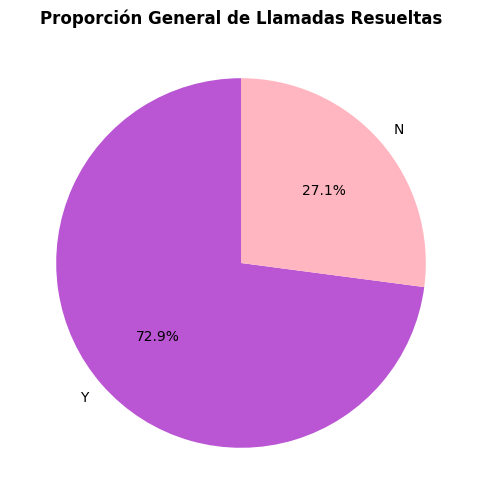

In [19]:
import matplotlib.pyplot as plt

# KPI 1: Tasa de Resolución en la llamada

# Contamos el total de registros y cuántos se resolvieron
total_llamadas = len(df)
llamadas_resueltas = len(df[df['Resolved'] == 'Y'])

# Sacamos el porcentaje general de la base
cr_porcentaje = (llamadas_resueltas / total_llamadas) * 100
print(f"KPI 1 - Tasa de Resolución en la Llamada: {cr_porcentaje:.2f}%\n")

# Contamos cuántas llamadas se resolvieron y cuántas no para el gráfico
resolucion_counts = df['Resolved'].value_counts()

# Graficamos un pastel que represente bien lo que tenemos en nuestro Dataset
grafico_kpi1 = resolucion_counts.plot(
    kind='pie',
    figsize=(6, 6),
    autopct='%1.1f%%',
    colors=['mediumorchid', 'lightpink'],
    startangle=90
)

# Ponemos los textos claros
grafico_kpi1.set_title('Proporción General de Llamadas Resueltas', fontsize=12, fontweight='bold')
grafico_kpi1.set_ylabel('')
plt.show() # Añadir para mostrar el gráfico


## KPI 2: Tiempo Promedio de Respuesta

**Calculo:** Promediamos la columna `Speed of answer in seconds`, pero solo consideramos las filas donde la llamada fue efectivamente contestada, porque las llamadas abandonadas no tienen tiempo de respuesta real.

la formula utilizada fue la siguiente:

$$ASA = \frac{\sum \text{Speed of answer (llamadas contestadas)}}{\text{Total llamadas contestadas}}$$

**Indicador:** Mide el tiempo de espera promedio en segundos que el usuario experimenta antes de lograr conectarse con un agente humano.

**Interpretación de Negocio:**
Este indicador nos da una idea clara de si la infraestructura actual y el equipo de trabajo son suficientes para manejar el flujo de llamadas. Si el ASA nos sale muy alto, es una señal de que el sistema de atención está saturado o que nos hace falta contratar más personal para evitar que los usuarios esperen demasiado.

Total llamadas contestadas : 4054
ASA (seg)                  : 67.52 segundos
ASA (min)                  : 1.13 minutos


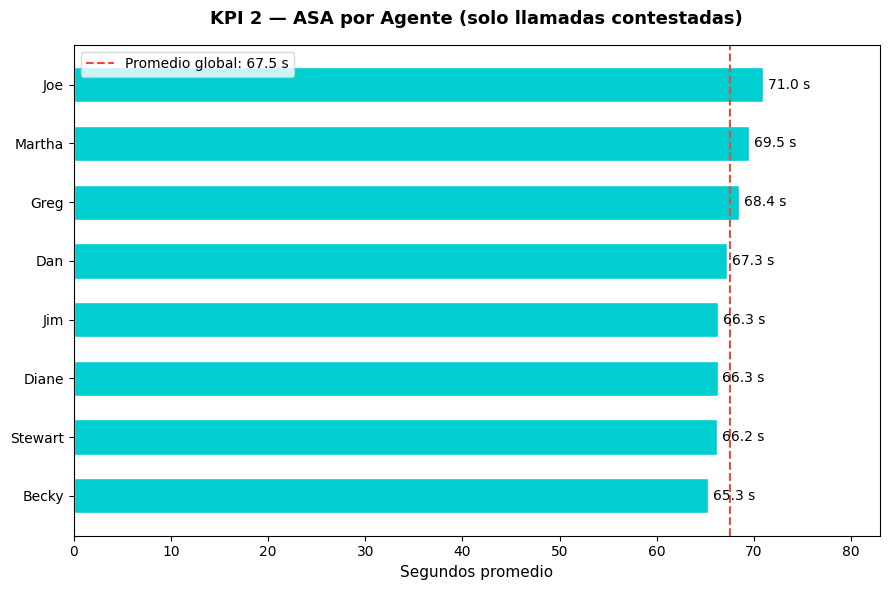

In [24]:
import matplotlib.pyplot as plt

# KPI 2: Tiempo Promedio de Respuesta

# Filtramos las llamadas contestadas ('Y').
# Si metemos las que no se contestaron, el promedio no saldra como esperamos
llamadas_contestadas = df[df['Answered (Y/N)'] == 'Y']

# Sacamos el promedio de la velocidad de respuesta.
# Como ya limpiamos los datos antes, el mean() no nos va a dar error con los vacíos
asa_promedio = llamadas_contestadas['Speed of answer in seconds'].mean()

print(f'Total llamadas contestadas : {len(llamadas_contestadas)}')
print(f'ASA (seg)                  : {asa_promedio:.2f} segundos')
print(f'ASA (min)                  : {asa_promedio/60:.2f} minutos')

# Gráfica: ASA de barras horizontales

# Agrupamos por agente y ordenamos los promedios de menor a mayor.
# Así en el gráfico se ve quien responde mas rapido y quien no
asa_por_agente = (llamadas_contestadas
                  .groupby('Agent')['Speed of answer in seconds']
                  .mean()
                  .sort_values(ascending=True))

# Creamos el gráfico con un tamaño cómodo para que no se vea amontonado.
fig, ax = plt.subplots(figsize=(9, 6))

# Usamos un color agradable a la vista (para mi)
bars = ax.barh(asa_por_agente.index, asa_por_agente.values,
               color='#00CED1', edgecolor='white', height=0.6)

# Ponemos una línea roja punteada para marcar el promedio general.
ax.axvline(asa_promedio, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Promedio global: {asa_promedio:.1f} s')

# Ponemos los segundos exactos al lado de cada barra
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f} s', va='center', fontsize=10)

# colocams los nombres de los titulos y ejes para no perdernos
ax.set_xlabel('Segundos promedio', fontsize=11)
ax.set_title('KPI 2 — ASA por Agente (solo llamadas contestadas)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_xlim(0, asa_por_agente.max() + 12)
plt.tight_layout()
plt.show()


## KPI 3: Nivel de Satisfacción del Cliente (promedio)

**Cálculo:** Promediamos la columna `Satisfaction rating` sobre todos los registros que tienen calificación. La escala va de 1 (mínimo) a 5 (máximo).

la formula fue la siguiente:

$$CSAT = \frac{\sum \text{Satisfaction rating}}{\text{Total calificaciones válidas}}$$


**Indicador:** Evalúa la percepción de calidad del servicio entregado por la empresa desde el punto de vista del cliente.

**Interpretación de Negocio:** Con un promedio de 3.40 sobre 5, estamos apenas por encima del punto neutro, y eso es una señal clara de que hay que ponerse las pilas. Si logramos bajar los tiempos de espera y mejorar la tasa de resolución, lo más lógico es que esta calificación suba y los clientes se sientan mucho más cómodos con nosotros a largo plazo.

Calificaciones válidas : 4054
CSAT Promedio          : 3.40 / 5

Distribución de ratings:
Satisfaction rating
1.0     417
2.0     396
3.0    1218
4.0    1180
5.0     843
Name: count, dtype: int64


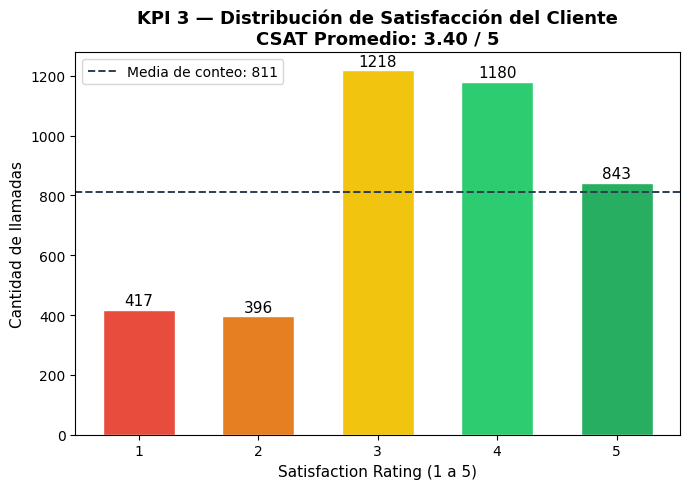

In [26]:
# KPI 3: Nivel de Satisfacción del Cliente

# mean() ya ignora los NaN que quedaron de celdas vacías en la limpieza inicial
csat_promedio = df['Satisfaction rating'].mean()

# Contamos cuántas calificaciones válidas hay (no NaN)
calificaciones_validas = df['Satisfaction rating'].notna().sum()

print(f'Calificaciones válidas : {calificaciones_validas}')
print(f'CSAT Promedio          : {csat_promedio:.2f} / 5')

# Distribuimos las frecuencias por rating
distribucion = df['Satisfaction rating'].value_counts().sort_index()
print(f'\nDistribución de ratings:')
print(distribucion)

# Gráfica KPI 3: Distribución de Satisfaction rating
colores_rating = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(distribucion.index.astype(int), distribucion.values,
              color=colores_rating, edgecolor='white', width=0.6)

# Etiqueta de cantidad en cada barra para poder identificar facilmente
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            str(int(bar.get_height())),
            ha='center', fontsize=11)

# Línea horizontal con el promedio
ax.axhline(distribucion.mean(), color='#2c3e50', linestyle='--',
           linewidth=1.4, label=f'Media de conteo: {distribucion.mean():.0f}')

ax.set_xlabel('Satisfaction Rating (1 a 5)', fontsize=11)
ax.set_ylabel('Cantidad de llamadas', fontsize=11)
ax.set_title(f'KPI 3 — Distribución de Satisfacción del Cliente\nCSAT Promedio: {csat_promedio:.2f} / 5',
             fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## KPI 4: Volumen de Llamadas y Tasa de Abandono por Agente

**Cálculo:** Agrupamos por agente y contamos el total de llamadas asignadas. Luego contamos las llamadas con `Answered (Y/N) == 'N'` y calculamos el porcentaje sobre el total de cada agente.

formula utilizada:

$$\text{Tasa de Abandono}_i = \frac{\text{Llamadas no contestadas del agente } i}{\text{Total llamadas del agente } i} \times 100$$

**Indicador:** Básicamente, vemos qué tanta carga de trabajo tiene cada agente y quién está perdiendo más llamadas. Nos sirve para identificar dónde se nos está "cayendo" el servicio.

**Interpretación de Negocio:**
Saltan casos como el de Diane, que tiene la tasa de abandono más alta (20.85%). Esto es una señal de alerta de que algo no anda bien: o la tienen sobrecargada de trabajo o el sistema está enviando mal las llamadas a su cola. Con este dato, la gerencia puede reequilibrar la carga entre todos los agentes o ver si hace falta reforzar la capacitación de quienes tienen más dificultades.

Volumen de llamadas y Tasa de Abandono por Agente:


,Total_Llamadas,No_Contestadas,Tasa_Abandono_%
Agent,,,
Diane,633,132,20.85
Greg,624,122,19.55
Jim,666,130,19.52
Martha,638,124,19.44
Joe,593,109,18.38
Becky,631,114,18.07
Stewart,582,105,18.04
Dan,633,110,17.38


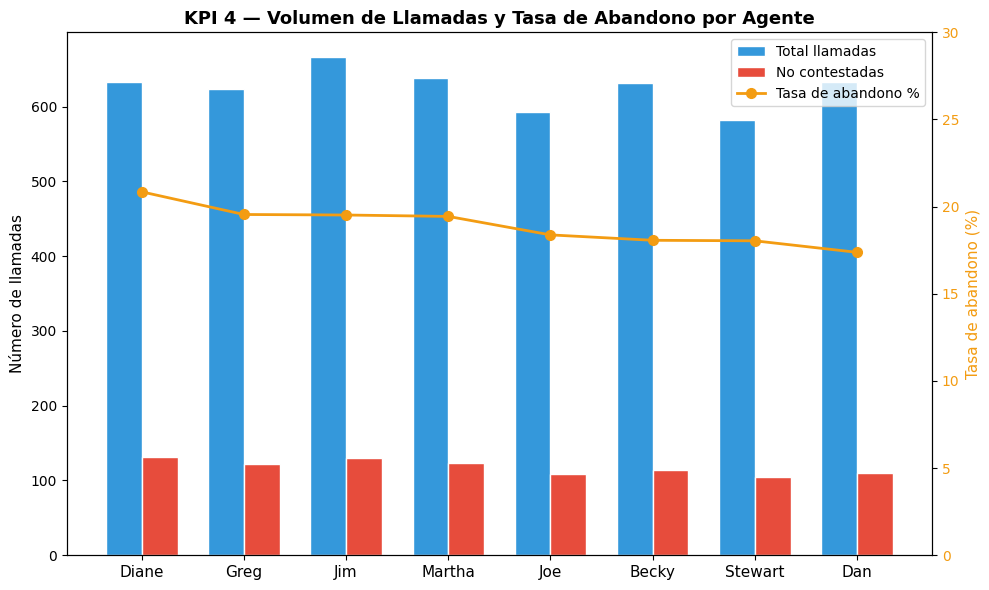

In [27]:
# KPI 4: Volumen de Llamadas y Tasa de Abandono por Agente

# Contamos el total de llamadas que tiene asignado cada agente
volumen_total = df.groupby('Agent').size().rename('Total_Llamadas')

# Filtramos las llamadas NO contestadas y las agrupamos por agente
no_contestadas = (df[df['Answered (Y/N)'] == 'N']
                  .groupby('Agent')
                  .size()
                  .rename('No_Contestadas'))

# Unimos ambas series en un solo dataframe
# fillna(0) por si algún agente no tiene ninguna llamada abandonada
kpi4 = pd.concat([volumen_total, no_contestadas], axis=1).fillna(0).astype(int)

# Calculamos el porcentaje de abandono redondeado a 2 decimales
kpi4['Tasa_Abandono_%'] = (kpi4['No_Contestadas'] / kpi4['Total_Llamadas'] * 100).round(2)

# Ordenamos de mayor a menor tasa de abandono para identificar rápido el cuello de botella
kpi4 = kpi4.sort_values('Tasa_Abandono_%', ascending=False)

print('Volumen de llamadas y Tasa de Abandono por Agente:')
display(kpi4)

# Gráfica KPI 4: Barras agrupadas (Total vs No contestadas) con línea de tasa
agentes     = kpi4.index.tolist()
x           = np.arange(len(agentes))
ancho_barra = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras de total de llamadas
b1 = ax1.bar(x - ancho_barra / 2, kpi4['Total_Llamadas'],
              width=ancho_barra, label='Total llamadas',
              color='#3498db', edgecolor='white')

# Barras de llamadas no contestadas encima del mismo eje
b2 = ax1.bar(x + ancho_barra / 2, kpi4['No_Contestadas'],
              width=ancho_barra, label='No contestadas',
              color='#e74c3c', edgecolor='white')

ax1.set_ylabel('Número de llamadas', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(agentes, fontsize=11)

# Segundo eje Y para la tasa de abandono en porcentaje
ax2 = ax1.twinx()
ax2.plot(x, kpi4['Tasa_Abandono_%'], color='#f39c12',
         marker='o', linewidth=2, markersize=7,
         label='Tasa de abandono %')
ax2.set_ylabel('Tasa de abandono (%)', fontsize=11, color='#f39c12')
ax2.tick_params(axis='y', labelcolor='#f39c12')
ax2.set_ylim(0, 30)

# Unimos las leyendas de ambos ejes en una sola
lineas1, etiq1 = ax1.get_legend_handles_labels()
lineas2, etiq2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiq1 + etiq2, loc='upper right', fontsize=10)

ax1.set_title('KPI 4 — Volumen de Llamadas y Tasa de Abandono por Agente',
               fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Resumen de los 4 KPIs

resumen = pd.DataFrame({
    'KPI': [
        'KPI 1 — Tasa de Resolución',
        'KPI 2 — Tiempo Promedio de Respuesta',
        'KPI 3 — Satisfacción del Cliente',
        'KPI 4 — Tasa de Abandono más alta'
    ],
    'Valor': [
        f'{cr_porcentaje:.2f}%',
        f'{asa_promedio:.2f} s',
        f'{csat_promedio:.2f} / 5',
        f"{kpi4['Tasa_Abandono_%'].max():.2f}%"
    ],
    'Interpretación resumida': [
        'El 72.92% de las llamadas se resuelven en el primer contacto.',
        'Los clientes esperan en promedio 67.52 segundos antes de ser atendidos.',
        'La satisfacción promedio es 3.40/5, apenas por encima del punto neutro.',
        'Diane tiene la tasa más alta de abandono con 20.85% de sus llamadas perdidas.'
    ]
})

display(resumen)

,KPI,Valor,Interpretación resumida
0,KPI 1 — Tasa de Resolución,72.92%,El 72.92% de las llamadas se resuelven en el p...
1,KPI 2 — Tiempo Promedio de Respuesta,67.52 s,Los clientes esperan en promedio 67.52 segundo...
2,KPI 3 — Satisfacción del Cliente,3.40 / 5,"La satisfacción promedio es 3.40/5, apenas por..."
3,KPI 4 — Tasa de Abandono más alta,20.85%,Diane tiene la tasa más alta de abandono con 2...
